# Computer Vision Assignment 2 - B00150982


In [229]:
from __future__ import print_function

from tensorflow import keras
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tf_explain.core.grad_cam import GradCAM
from sklearn.metrics import classification_report
import tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Rescaling, BatchNormalization 
from keras.optimizers import RMSprop,Adam 
import matplotlib.pyplot as plt
import numpy as np

In [206]:
batch_size = 12
num_classes = 3
epochs = 8
img_width = 128
img_height = 128
img_channels = 3
fit = True

train_dir = "c:/Users/diana/Documents/CompVision/dataset/chest_xray/chest_xray/train"
test_dir = "c:/Users/diana/Documents/CompVision/dataset/chest_xray/chest_xray/test"

## Dataset balance

In [207]:
bacterial_count = len(os.listdir(train_dir + "/BACTERIAL"))
normal_count = len(os.listdir(train_dir + "/NORMAL"))
viral_count = len(os.listdir(train_dir + "/VIRAL"))

print("Dataset distribution:")
print("BACTERIAL:", bacterial_count)
print("NORMAL:", normal_count)
print("VIRAL:", viral_count)

total = bacterial_count + normal_count + viral_count
print("Total images:", total)

Dataset distribution:
BACTERIAL: 2596
NORMAL: 1461
VIRAL: 1363
Total images: 5420


## Load dataset

In [208]:
train_ds,val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        train_dir,
        seed=123,
        validation_split=0.2,
        subset='both',
        image_size=(img_height, img_width),
        batch_size=batch_size,
        labels='inferred',
        shuffle=True
)
    
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        test_dir,
        seed=None,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        labels='inferred',
        shuffle=False
)

class_names = train_ds.class_names
print('Class Names: ',class_names)
num_classes = len(class_names)

Found 5419 files belonging to 3 classes.
Using 4336 files for training.
Using 1083 files for validation.
Found 437 files belonging to 3 classes.
Class Names:  ['BACTERIAL', 'NORMAL', 'VIRAL']


In [209]:
# Load pretrained base model
base_model = MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

## Visualise images

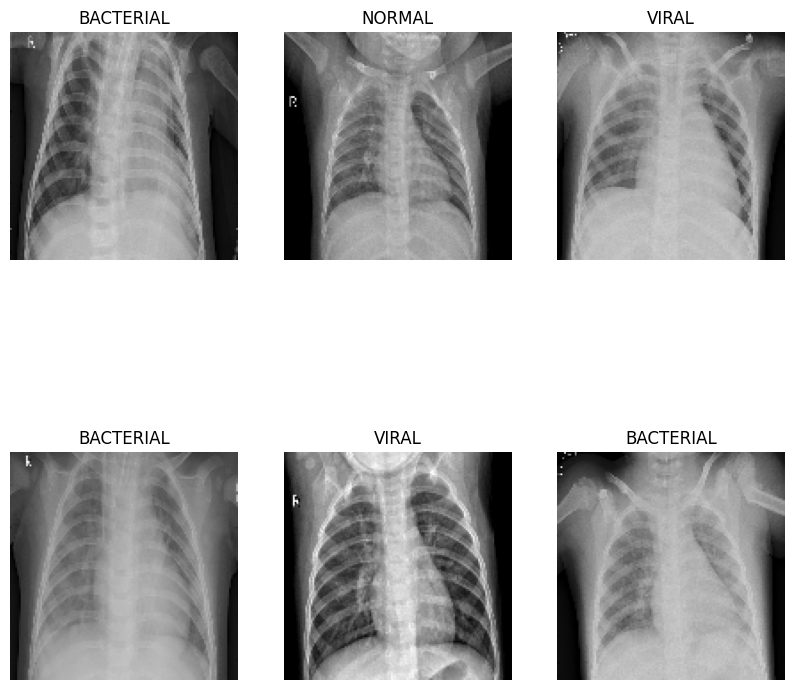

In [210]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(2):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
plt.show()

## Augmentation layer

In [211]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
])

In [194]:
#create model
#model = tf.keras.models.Sequential([
#    data_augmentation,
#    Rescaling(1.0/255),
#    Conv2D(16, (3,3), activation = 'relu', input_shape = (img_height,img_width, img_channels)),
#    MaxPooling2D(2,2),
#    Conv2D(32, (3,3), activation = 'relu'),
#    MaxPooling2D(2,2),
#    Conv2D(32, (3,3), activation = 'relu'),
#    MaxPooling2D(2,2),
#    GlobalAveragePooling2D(),
#    Dense(128,activation='relu'),
#    Dropout(0.3),
#    Dense(num_classes, activation = 'softmax')
#])

In [212]:
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
output = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)
model = tf.keras.Model(inputs=base_model.input, outputs=output)

In [213]:
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [214]:
save_callback = tf.keras.callbacks.ModelCheckpoint(
    "pneumonia.keras",
    save_best_only=True
)

In [215]:
class_weight = {
    0: 1.0,   # BACTERIAL
    1: 1.8,   # NORMAL
    2: 1.8    # VIRAL
}

print(class_names)

['BACTERIAL', 'NORMAL', 'VIRAL']


## Train model

In [216]:
history = model.fit(
        train_ds,
        validation_data=val_ds,
        callbacks=[save_callback],
        class_weight=class_weight,
        epochs=epochs)

Epoch 1/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 77s 194ms/step - accuracy: 0.6684 - loss: 1.0900 - val_accuracy: 0.7387 - val_loss: 0.6663
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 69s 191ms/step - accuracy: 0.7288 - loss: 0.9245 - val_accuracy: 0.7341 - val_loss: 0.6522
Epoch 3/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 64s 174ms/step - accuracy: 0.7373 - loss: 0.8949 - val_accuracy: 0.7368 - val_loss: 0.6384
Epoch 4/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 63s 172ms/step - accuracy: 0.7401 - loss: 0.8597 - val_accuracy: 0.7396 - val_loss: 0.6374
Epoch 5/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 68s 187ms/step - accuracy: 0.7389 - loss: 0.8423 - val_accuracy: 0.7341 - val_loss: 0.6168
Epoch 6/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 71s 196ms/step - accuracy: 0.7500 - loss: 0.8324 - val_accuracy: 0.7442 - val_loss: 0.6081
Epoch 7/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 68s 188ms/step - accuracy: 0.7512 - loss: 0.8127 - val_accuracy: 0.7525 - val_loss: 0.6078
Epoch 8/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 66s 183ms/step - accuracy: 0.7578 - loss: 0.7962 - 

## Evaluate model

In [217]:
score = model.evaluate(test_ds, batch_size=batch_size)
print('Test accuracy:', score[1])

37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - accuracy: 0.7643 - loss: 0.5984
Test accuracy: 0.7643020749092102


In [218]:
# Generate predictions
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 161ms/step
              precision    recall  f1-score   support

   BACTERIAL       0.74      0.78      0.76       184
      NORMAL       0.78      0.96      0.86       122
       VIRAL       0.78      0.56      0.65       131

    accuracy                           0.76       437
   macro avg       0.77      0.77      0.76       437
weighted avg       0.77      0.76      0.76       437



## GradCAM

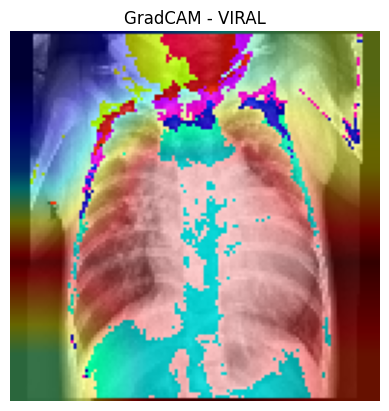

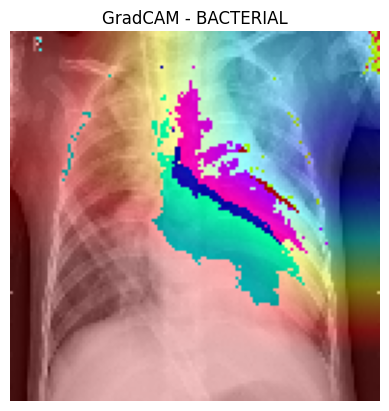

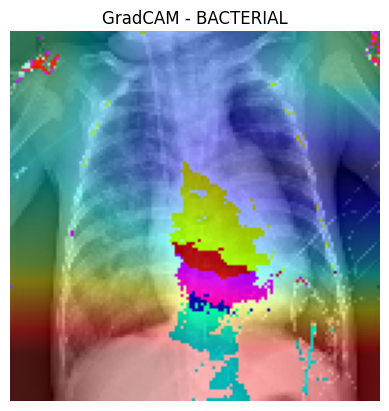

In [247]:
for images, labels in test_ds.take(1):
    for i in range(3):

        img = images[i]
        img_array = tf.expand_dims(img, axis=0)

        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(img_array)
            pred_index = tf.argmax(predictions[0])
            loss = predictions[:, pred_index]

        grads = tape.gradient(loss, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        conv_outputs = conv_outputs[0]
        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)

        heatmap = tf.maximum(heatmap, 0)
        if tf.reduce_max(heatmap) != 0:
            heatmap /= tf.reduce_max(heatmap)

        heatmap = heatmap.numpy()
        heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        superimposed_img = heatmap * 0.4 + img.numpy()

        plt.imshow(superimposed_img.astype("uint8"))
        plt.title(f"GradCAM - {class_names[int(pred_index)]}")
        plt.axis("off")
        plt.show()

## Plot accuracy

C:\Users\diana\AppData\Local\Temp\ipykernel_29056\293871340.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


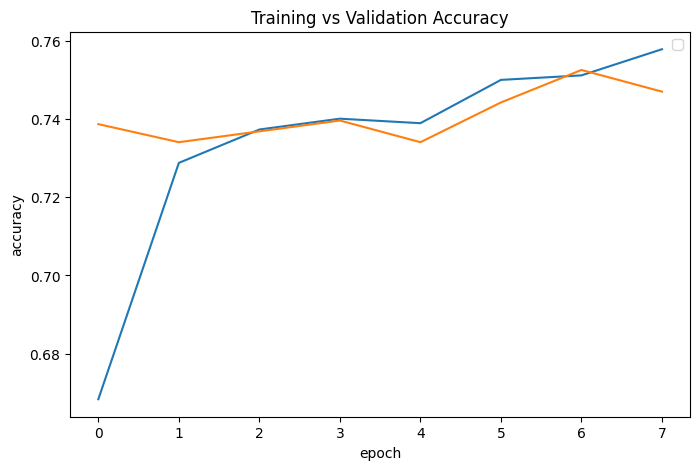

In [219]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training vs Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

C:\Users\diana\AppData\Local\Temp\ipykernel_29056\2512735038.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


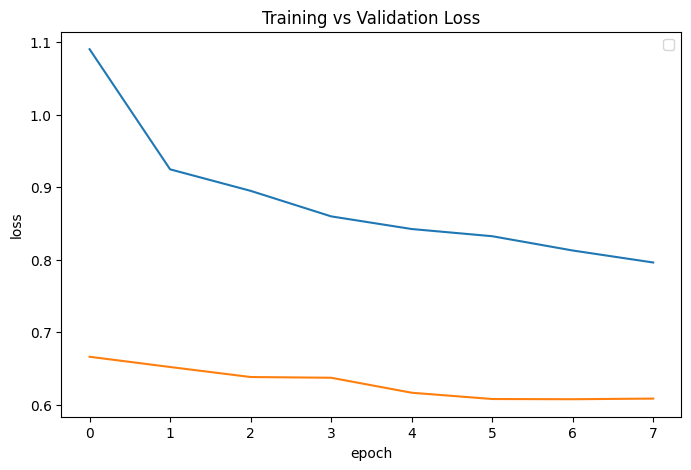

In [221]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training vs Validation Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

## Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


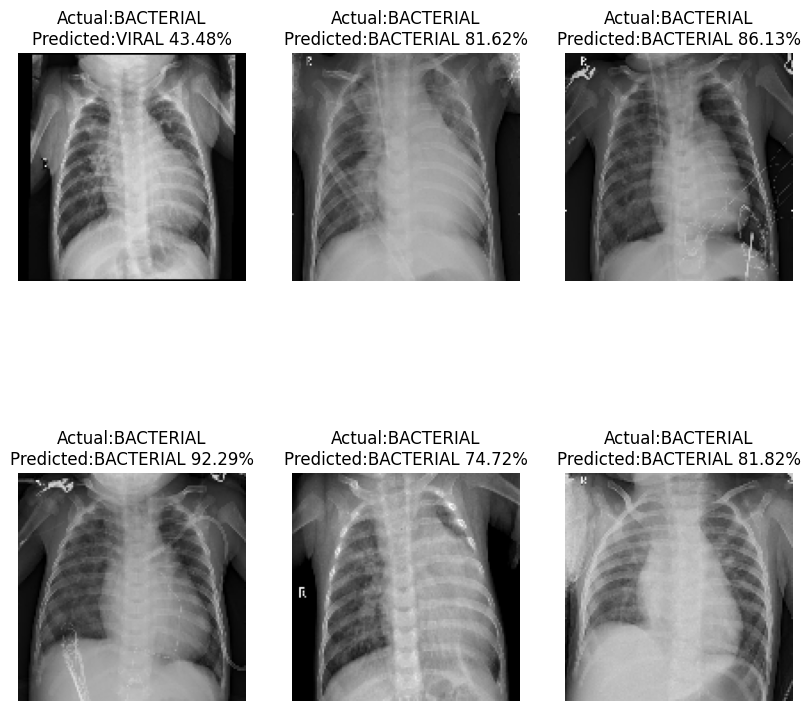

In [222]:
test_batch = test_ds.take(1)
plt.figure(figsize=(10, 10))
for images, labels in test_batch:
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        prediction = model.predict(tf.expand_dims(images[i].numpy(),0))#perform a prediction on this image
        plt.title('Actual:' + class_names[labels[i].numpy()]+ '\nPredicted:{} {:.2f}%'.format(class_names[np.argmax(prediction)], 100 * np.max(prediction)))
        plt.axis("off")
    plt.show()